In [1]:
import cv2
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

In [2]:
print(os.getcwd())
print(os.listdir("data/san_francisco"))

c:\Dev\projects
['san_1.bmp', 'san_2.bmp', 'san_gt.bmp']


In [3]:
img1 = cv2.imread("data/san_francisco/san_1.bmp", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("data/san_francisco/san_2.bmp", cv2.IMREAD_GRAYSCALE)
gt = cv2.imread("data/san_francisco/san_gt.bmp", cv2.IMREAD_GRAYSCALE)

print(img1.shape, img2.shape, gt.shape)

(256, 256) (256, 256) (256, 256)


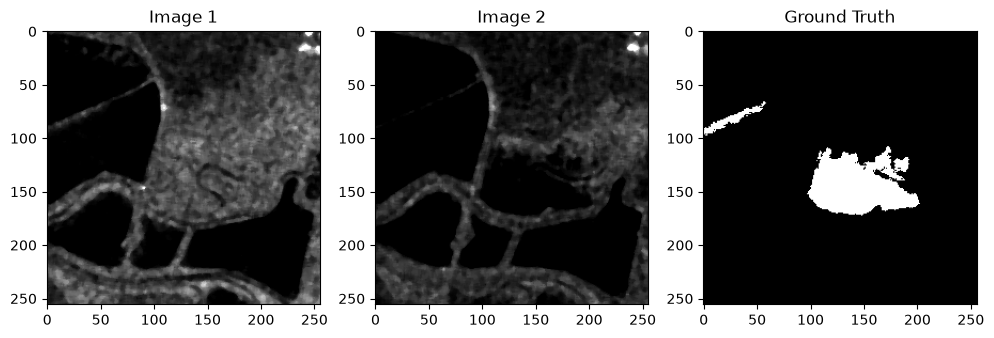

In [4]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img1, cmap='gray'); plt.title("Image 1")
plt.subplot(1, 3, 2); plt.imshow(img2, cmap='gray'); plt.title("Image 2")
plt.subplot(1, 3, 3); plt.imshow(gt, cmap='gray'); plt.title("Ground Truth")
plt.show()

San_1 and san_2 look nearly identical, but somewhere in there pixels have changed. We need to highlight where they changed. Simply subtracting one image from the other works for optical images, but SAR has speckle noise that makes subtraction messy.

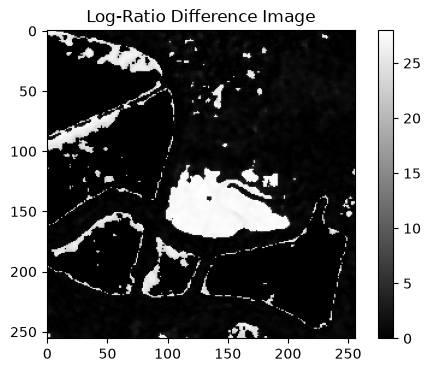

In [5]:
img1_float = img1.astype(np.float32) + 1e-10
img2_float = img2.astype(np.float32) + 1e-10
log_ratio = np.abs(np.log(img1_float)-np.log(img2_float))

plt.figure(figsize=(6, 4))
plt.imshow(log_ratio, cmap='gray')
plt.title("Log-Ratio Difference Image")
plt.colorbar()
plt.show()

The log-ratio image is a rough estimate of change it caught the real changed areas (matching gt) but also flagged extra patches that aren't actually changed. That's just SAR noise being picked up.
The CNN's job is to learn the difference between "this bright patch is real change" and "this bright patch is just noise." It does that by also looking at the surrounding context (the neighbourhood of pixels around each point), not just one pixel in isolation.

In [6]:
patch_size = 7
half = patch_size//2
padded = np.pad(log_ratio, half, mode='constant', constant_values=0)

In [7]:
patches, labels = [], []
for i in range(256):
    for j in range(256):
        patch = padded[i:i+patch_size, j:j+patch_size]
        patches.append(patch)
        labels.append(1 if gt[i,j] > 128 else 0)

patches = np.array(patches)
labels = np.array(labels)

print(patch.shape, labels.shape)
print("Changed pixels:", labels.sum())          # only 7% (class imbalance)
print("Unchanged pixels:", (labels == 0).sum())

(7, 7) (65536,)
Changed pixels: 4685
Unchanged pixels: 60851


In [8]:
X = patches[:, np.newaxis, :, :]
y = labels

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X.shape, y.shape

(torch.Size([65536, 1, 7, 7]), torch.Size([65536]))

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32*1*1, 64)
        self.fc2 = nn.Linear(64, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 32*1*1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
  (relu): ReLU()
)


In [10]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

weights = torch.tensor([1.0, 13.0])
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(f"Total batches per epoch: {len(dataloader)}")

Total batches per epoch: 256


In [11]:
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")


Epoch 1/20 - Loss: 0.1089
Epoch 2/20 - Loss: 0.0674
Epoch 3/20 - Loss: 0.0629
Epoch 4/20 - Loss: 0.0543
Epoch 5/20 - Loss: 0.0557
Epoch 6/20 - Loss: 0.0513
Epoch 7/20 - Loss: 0.0524
Epoch 8/20 - Loss: 0.0475
Epoch 9/20 - Loss: 0.0442
Epoch 10/20 - Loss: 0.0445
Epoch 11/20 - Loss: 0.0415
Epoch 12/20 - Loss: 0.0458
Epoch 13/20 - Loss: 0.0443
Epoch 14/20 - Loss: 0.0420
Epoch 15/20 - Loss: 0.0563
Epoch 16/20 - Loss: 0.0517
Epoch 17/20 - Loss: 0.0509
Epoch 18/20 - Loss: 0.0487
Epoch 19/20 - Loss: 0.0409
Epoch 20/20 - Loss: 0.0471


In [12]:
model.eval()

with torch.no_grad():
    outputs = model(X)
    predictions = torch.argmax(outputs, dim=1).numpy

TP = ((predictions == 1) & (labels==1)).sum()
TN = ((predictions == 0) & (labels==0)).sum()
FP = ((predictions == 1) & (labels==0)).sum()
FN = ((predictions == 0) & (labels==1)).sum()

OE = FP + FN
PCC = (TP+TN)/(TP+TN+FP+FN) * 100
KC = (2 * (TP * TN - FP * FN)) / ((TP + FP )* (FP + TN) + (TP + FN) + (FN + TN)) * 100

print(f"FP:  {FP}")
print(f"FN:  {FN}")
print(f"OE:  {OE}")
print(f"PCC: {PCC:.2f}%")
print(f"KC:  {KC:.2f}%")

FP:  0
FN:  0
OE:  0
PCC: nan%
KC:  nan%


C:\Users\iusan\AppData\Local\Temp\ipykernel_25512\2566085565.py:13: RuntimeWarning: invalid value encountered in scalar divide
  PCC = (TP+TN)/(TP+TN+FP+FN) * 100
C:\Users\iusan\AppData\Local\Temp\ipykernel_25512\2566085565.py:14: RuntimeWarning: invalid value encountered in scalar divide
  KC = (2 * (TP * TN - FP * FN)) / ((TP + FP )* (FP + TN) + (TP + FN) + (FN + TN)) * 100


In [13]:
print("Predictions:", predictions[:20])
print("Labels:", labels[:20])
print("Predictions dtype:", predictions.dtype)
print("Labels dtype:", labels.dtype)
print("Unique predictions:", np.unique(predictions))
print("Unique labels:", np.unique(labels))

TypeError: 'builtin_function_or_method' object is not subscriptable

In [14]:
print(type(predictions))

<class 'builtin_function_or_method'>


In [15]:
model.eval()

with torch.no_grad():
    outputs = model(X)
    print(type(outputs))
    print(outputs.shape)

<class 'torch.Tensor'>
torch.Size([65536, 2])


In [16]:
with torch.no_grad():
    outputs = model(X)
    predictions = torch.argmax(outputs, dim=1).numpy()
    print(type(predictions))
    print(predictions.shape)
    print(np.unique(predictions))

<class 'numpy.ndarray'>
(65536,)
[0 1]


In [17]:
TP = ((predictions == 1) & (labels == 1)).sum()
TN = ((predictions == 0) & (labels == 0)).sum()
FP = ((predictions == 1) & (labels == 0)).sum()
FN = ((predictions == 0) & (labels == 1)).sum()

OE = FP + FN
PCC = (TP + TN) / (TP + TN + FP + FN) * 100
KC = (2 * (TP * TN - FP * FN)) / ((TP + FP) * (FP + TN) + (TP + FN) * (FN + TN)) * 100

print(f"FP:  {FP}")
print(f"FN:  {FN}")
print(f"OE:  {OE}")
print(f"PCC: {PCC:.2f}%")
print(f"KC:  {KC:.2f}%")

FP:  1830
FN:  34
OE:  1864
PCC: 97.16%
KC:  81.80%


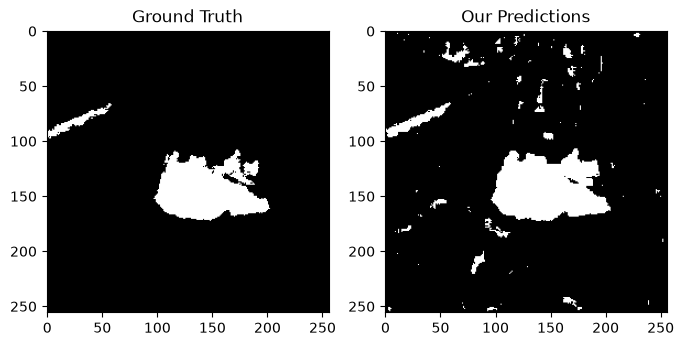

In [18]:
pred_map = predictions.reshape(256, 256)
gt_map = labels.reshape(256, 256)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(gt_map, cmap='gray'); plt.title("Ground Truth")
plt.subplot(1,2,2); plt.imshow(pred_map, cmap='gray'); plt.title("Our Predictions")
plt.show()

In [19]:
weights = torch.tensor([1.0, 5.0])
criterion = nn.CrossEntropyLoss(weight=weights)

In [20]:
model = CNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [21]:
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")


Epoch 1/20 - Loss: 0.2028
Epoch 2/20 - Loss: 0.0938
Epoch 3/20 - Loss: 0.0740
Epoch 4/20 - Loss: 0.0606
Epoch 5/20 - Loss: 0.0560
Epoch 6/20 - Loss: 0.0530
Epoch 7/20 - Loss: 0.0471
Epoch 8/20 - Loss: 0.0460
Epoch 9/20 - Loss: 0.0416
Epoch 10/20 - Loss: 0.0400
Epoch 11/20 - Loss: 0.0386
Epoch 12/20 - Loss: 0.0368
Epoch 13/20 - Loss: 0.0372
Epoch 14/20 - Loss: 0.0362
Epoch 15/20 - Loss: 0.0334
Epoch 16/20 - Loss: 0.0348
Epoch 17/20 - Loss: 0.0335
Epoch 18/20 - Loss: 0.0327
Epoch 19/20 - Loss: 0.0314
Epoch 20/20 - Loss: 0.0315


In [22]:
model.eval()

with torch.no_grad():
    outputs = model(X)
    print(type(outputs))
    print(outputs.shape)
with torch.no_grad():
    outputs = model(X)
    predictions = torch.argmax(outputs, dim=1).numpy()
    print(type(predictions))
    print(predictions.shape)
    print(np.unique(predictions))
TP = ((predictions == 1) & (labels == 1)).sum()
TN = ((predictions == 0) & (labels == 0)).sum()
FP = ((predictions == 1) & (labels == 0)).sum()
FN = ((predictions == 0) & (labels == 1)).sum()

OE = FP + FN
PCC = (TP + TN) / (TP + TN + FP + FN) * 100
KC = (2 * (TP * TN - FP * FN)) / ((TP + FP) * (FP + TN) + (TP + FN) * (FN + TN)) * 100

print(f"FP:  {FP}")
print(f"FN:  {FN}")
print(f"OE:  {OE}")
print(f"PCC: {PCC:.2f}%")
print(f"KC:  {KC:.2f}%")

<class 'torch.Tensor'>
torch.Size([65536, 2])
<class 'numpy.ndarray'>
(65536,)
[0 1]
FP:  624
FN:  39
OE:  663
PCC: 98.99%
KC:  92.79%


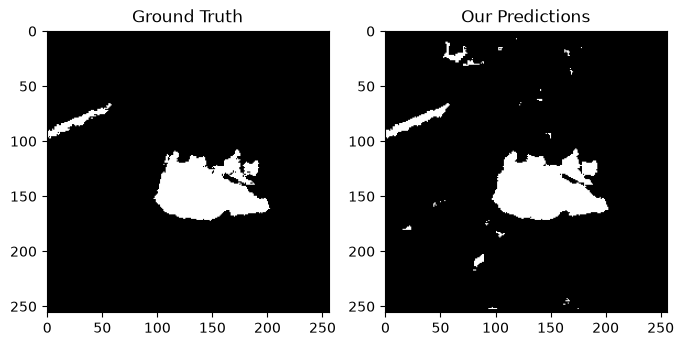

In [23]:
pred_map = predictions.reshape(256, 256)
gt_map = labels.reshape(256, 256)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(gt_map, cmap='gray'); plt.title("Ground Truth")
plt.subplot(1,2,2); plt.imshow(pred_map, cmap='gray'); plt.title("Our Predictions")
plt.show()

In [24]:
patch_size = 13
half = patch_size//2
padded = np.pad(log_ratio, half, mode='constant', constant_values=0)

In [25]:
patches, labels = [], []
for i in range(256):
    for j in range(256):
        patch = padded[i:i+patch_size, j:j+patch_size]
        patches.append(patch)
        labels.append(1 if gt[i,j] > 128 else 0)

patches = np.array(patches)
labels = np.array(labels)

print(patch.shape, labels.shape)
print("Changed pixels:", labels.sum())          # only 7% (class imbalance)
print("Unchanged pixels:", (labels == 0).sum())

(13, 13) (65536,)
Changed pixels: 4685
Unchanged pixels: 60851


In [26]:
X = patches[:, np.newaxis, :, :]
y = labels

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X.shape, y.shape

(torch.Size([65536, 1, 13, 13]), torch.Size([65536]))

In [27]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32*1*1, 64)
        self.fc2 = nn.Linear(64, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 32*1*1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
  (relu): ReLU()
)


In [28]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

weights = torch.tensor([1.0, 13.0])
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(f"Total batches per epoch: {len(dataloader)}")

Total batches per epoch: 256


In [29]:
epochs = 50

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")


ValueError: Expected input batch_size (2304) to match target batch_size (256).

print(type(predictions))